# Sephora Beauty Products Market Analysis

## Project Goal
This project analyzes Sephora beauty product data to understand pricing, customer ratings, product demand, and brand/category performance.

The goal is to identify business opportunities for launching a cosmetics e-commerce store in the U.S. market.

In [1]:
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns

df = pd.read_csv('product_info.csv')
cols_to_keep = [
    'brand_name',
    'product_name',
    'price_usd',
    'rating',
    'reviews',
    'loves_count',
    'primary_category'
]
df = df[cols_to_keep].copy()
df = df.dropna(subset=['price_usd','rating','reviews','primary_category'])
df.head()

,brand_name,product_name,price_usd,rating,reviews,loves_count,primary_category
0,19-69,Fragrance Discovery Set,35.0,3.6364,11.0,6320,Fragrance
1,19-69,La Habana Eau de Parfum,195.0,4.1538,13.0,3827,Fragrance
2,19-69,Rainbow Bar Eau de Parfum,195.0,4.2500,16.0,3253,Fragrance
3,19-69,Kasbah Eau de Parfum,195.0,4.4762,21.0,3018,Fragrance
4,19-69,Purple Haze Eau de Parfum,195.0,3.2308,13.0,2691,Fragrance


## Dataset Shape

In [2]:
df.shape

(8216, 7)

## Insight

The dataset contains 8,216 products and 7 columns, which is a good size for performing meaningful data analysis.

This amount of data is sufficient to identify trends, patterns, and potential business opportunities.

## Data Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8216 entries, 0 to 8491
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand_name        8216 non-null   object 
 1   product_name      8216 non-null   object 
 2   price_usd         8216 non-null   float64
 3   rating            8216 non-null   float64
 4   reviews           8216 non-null   float64
 5   loves_count       8216 non-null   int64  
 6   primary_category  8216 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 513.5+ KB


### Insight

All columns contain complete data with no missing values, indicating that the dataset is clean and reliable for analysis.

The dataset includes a mix of numerical features (price, rating, reviews, loves_count) and categorical features (brand_name, product_name, primary_category), which allows for both statistical analysis and segmentation of the market.

## Statistical Summary

In [4]:
df.describe()

,price_usd,rating,reviews,loves_count
count,8216.000000,8216.000000,8216.000000,8.216000e+03
mean,51.228229,4.194513,448.545521,3.014086e+04
std,53.406409,0.516694,1101.982529,6.699038e+04
min,3.000000,1.000000,1.000000,0.000000e+00
25%,25.000000,3.981725,26.000000,4.156250e+03
50%,35.000000,4.289350,122.000000,1.044400e+04
75%,58.000000,4.530525,418.000000,2.779625e+04
max,1900.000000,5.000000,21281.000000,1.401068e+06


### Insight

The data shows a wide price range, from very affordable products ($3) to high-end luxury items ($1900), indicating the presence of multiple market segments.

The average rating is relatively high (around 4.19), which suggests that most products are generally well-received by customers.

Additionally, the large variation in the number of reviews and loves_count indicates that some products have significantly higher demand and customer engagement compared to others.

## Business Questions

1. What are the most common product categories?
2. Which categories have the highest average price?
3. Which brands have the most products?
4. What products show high demand based on reviews and loves count?
5. Is there a relationship between price and rating?
6. What product types could be good opportunities for e-commerce?

## 1.What are the most common product categories?

In [5]:
category_counts = df['primary_category'].value_counts()
category_counts

primary_category
Skincare           2351
Makeup             2328
Hair               1416
Fragrance          1339
Bath & Body         395
Mini Size           274
Men                  59
Tools & Brushes      50
Gifts                 4
Name: count, dtype: int64

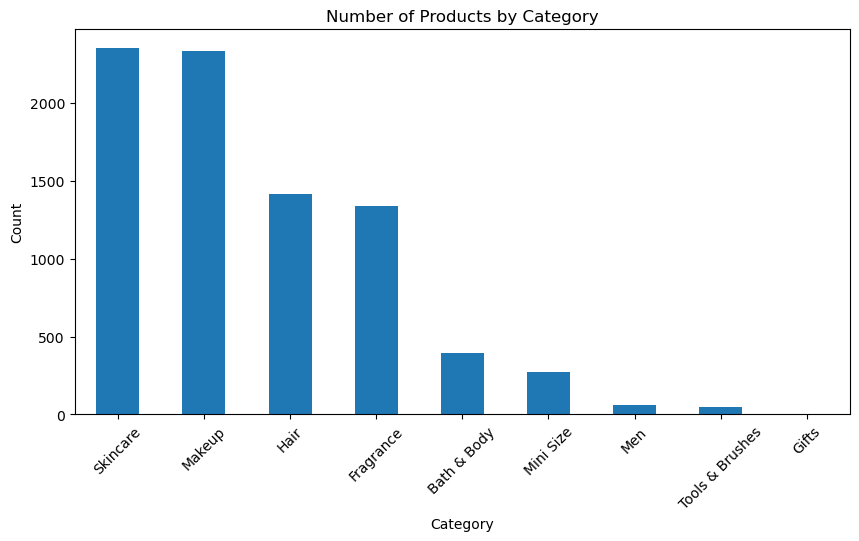

In [6]:
import matplotlib.pyplot as plt

category_counts.plot(kind='bar', figsize=(10,5))
plt.title('Number of Products by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


### Insight

Skincare and Makeup clearly dominate the market in terms of product availability, indicating both high demand and intense competition.

This suggests that entering these categories would require strong differentiation to stand out.

On the other hand, smaller categories such as Men, Tools & Brushes, and Gifts show lower product counts, which may represent underserved niches with less competition and potential opportunities for new e-commerce businesses.


## 2.Which categories have the highest average price?

In [10]:
avg_price_by_category = df.groupby('primary_category')['price_usd'].mean().sort_values(ascending = False)
avg_price_by_category

primary_category
Fragrance          87.569828
Skincare           59.859103
Gifts              50.000000
Hair               42.781596
Bath & Body        42.165823
Makeup             32.740417
Men                32.576271
Tools & Brushes    32.099000
Mini Size          20.895985
Name: price_usd, dtype: float64

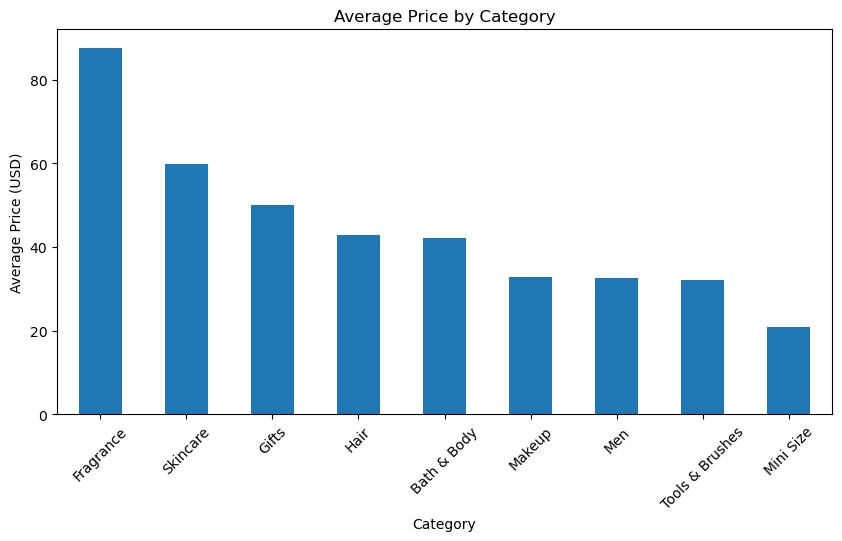

In [11]:
import matplotlib.pyplot as plt

avg_price_by_category.plot(kind='bar', figsize=(10,5))
plt.title('Average Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.show()

### Insight

Fragrance products have the highest average price among all categories, indicating a strong premium positioning in the market.

Skincare and Hair products also show relatively high average prices, suggesting good revenue potential.

In contrast, categories like Makeup and Mini Size have lower average prices, which may indicate higher accessibility but lower profit margins per product.

This suggests that while high-priced categories may offer better margins, they may also require stronger branding and customer trust to succeed.


## 3.Which brands have the most products?

In [14]:
top_brands = df['brand_name'].value_counts().head(10)
top_brands

brand_name
SEPHORA COLLECTION         351
CLINIQUE                   177
Dior                       133
tarte                      126
Bumble and bumble          107
Kérastase                  107
Charlotte Tilbury           98
TOM FORD                    97
Anastasia Beverly Hills     94
NEST New York               92
Name: count, dtype: int64

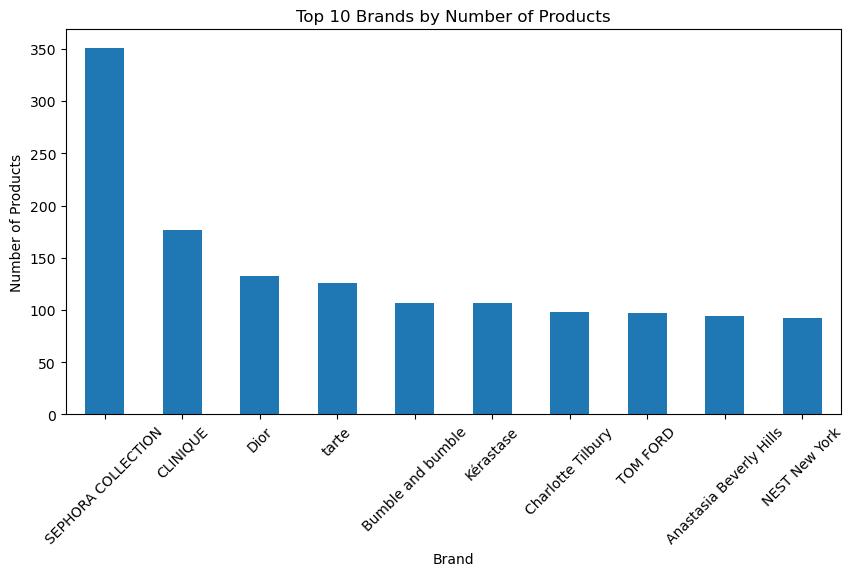

In [15]:
import matplotlib.pyplot as plt

top_brands.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Brands by Number of Products')
plt.xlabel('Brand')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

### Insight

A few brands dominate the dataset in terms of product count, with SEPHORA COLLECTION leading by a significant margin.

This indicates that these brands have a strong presence in the market, offering a wide range of products across different categories.

For a new e-commerce business, competing directly with these dominant brands may be challenging, so focusing on smaller or niche brands could provide a better opportunity to enter the market with less competition.


## 4.Which products show high demand based on reviews and loves count?

Reviews

In [16]:
top_reviewed = df.sort_values(by='reviews',ascending=False).head(10)
top_reviewed[['product_name','brand_name','price_usd','rating','reviews',]]

,product_name,brand_name,price_usd,rating,reviews
4250,Tattoo Liner Vegan Waterproof Liquid Eyeliner,KVD Beauty,25.0,4.1310,21281.0
7843,Better Than Sex Volumizing & Lengthening Mascara,Too Faced,28.0,3.7373,18610.0
5250,Blush,NARS,32.0,4.6643,18127.0
7978,24/7 Glide-On Waterproof Eyeliner Pencil,Urban Decay,25.0,4.3773,17179.0
2524,Pro Filt’r Soft Matte Longwear Liquid Foundation,Fenty Beauty by Rihanna,40.0,4.0356,16935.0
4431,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,4.3508,16118.0
247,Brow Wiz Ultra-Slim Precision Brow Pencil,Anastasia Beverly Hills,25.0,4.4056,15885.0
527,They're Real! Lengthening Mascara,Benefit Cosmetics,28.0,4.1242,15756.0
7852,Mini Better Than Sex Volumizing & Lengthening ...,Too Faced,16.0,3.7063,15620.0
7845,Born This Way Natural Finish Longwear Liquid F...,Too Faced,45.0,4.0437,14882.0


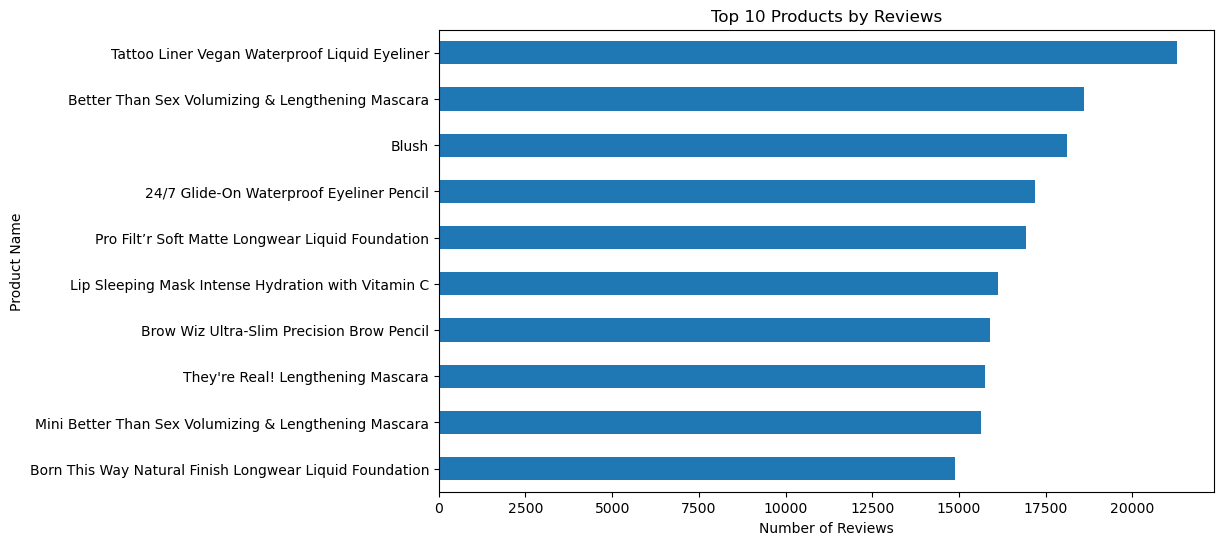

In [20]:

import matplotlib.pyplot as plt

top_reviewed.set_index('product_name')['reviews'].plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.show()

loves

In [19]:
top_loves = df.sort_values(by='loves_count', ascending=False).head(10)
top_loves[['product_name','brand_name','price_usd','rating','loves_count',]]

,product_name,brand_name,price_usd,rating,loves_count
6242,Soft Pinch Liquid Blush,Rare Beauty by Selena Gomez,23.0,4.5356,1401068
5249,Radiant Creamy Concealer,NARS,32.0,4.3080,1153594
4431,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,4.3508,1081315
6434,Cream Lip Stain Liquid Lipstick,SEPHORA COLLECTION,15.0,4.3201,1029051
2523,Gloss Bomb Universal Lip Luminizer,Fenty Beauty by Rihanna,21.0,4.6357,968317
2524,Pro Filt’r Soft Matte Longwear Liquid Foundation,Fenty Beauty by Rihanna,40.0,4.0356,856497
5250,Blush,NARS,32.0,4.6643,840076
247,Brow Wiz Ultra-Slim Precision Brow Pencil,Anastasia Beverly Hills,25.0,4.4056,834189
4458,Translucent Loose Setting Powder,Laura Mercier,43.0,4.5029,813497
7648,Niacinamide 10% + Zinc 1% Oil Control Serum,The Ordinary,6.0,4.2439,763168


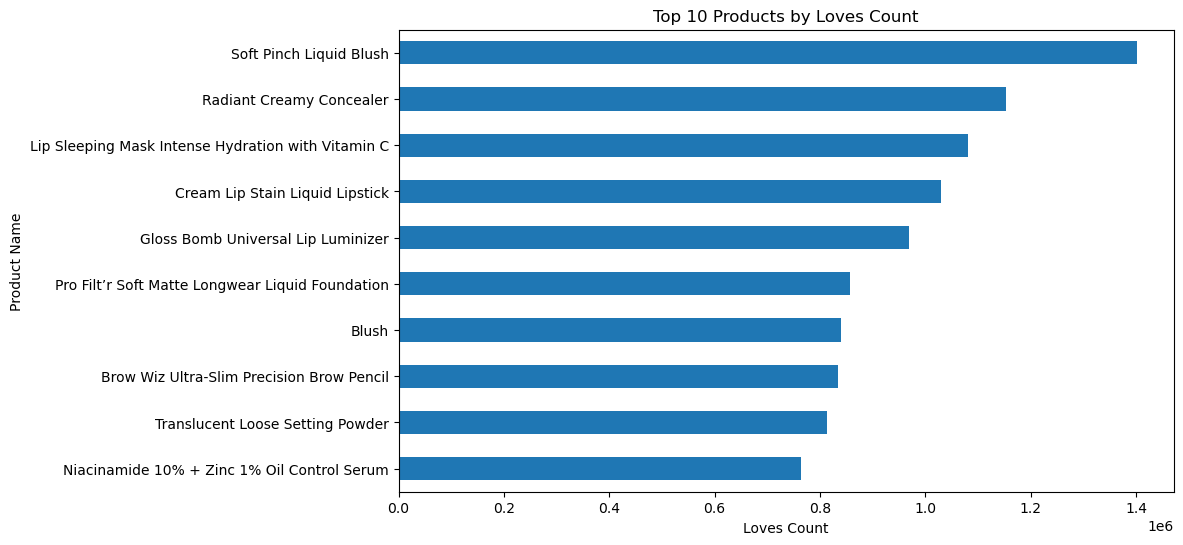

In [22]:
top_loves.set_index('product_name')['loves_count'].plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Loves Count')
plt.xlabel('Loves Count')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.show()


### Insight

The analysis shows that high-demand products are mostly concentrated in the Makeup and Skincare categories, including items such as mascara, foundation, blush, and serums.

These products consistently appear in both the top reviewed and most loved lists, indicating strong customer demand and engagement.

Additionally, most of these products fall within a low to mid price range ($20–$45), making them more accessible to a wider audience.

This suggests that affordable, everyday-use beauty products with strong brand recognition have the highest potential for success in an e-commerce business.


## 5.Is there a relationship between price and rating?

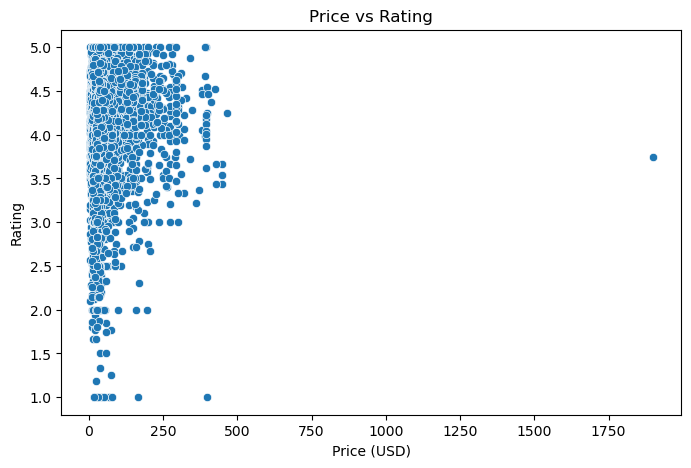

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='price_usd', y='rating')

plt.title('Price vs Rating')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.show()

### Insight

The scatter plot shows no strong relationship between price and rating.

Most products, regardless of their price, tend to have similar rating ranges, typically between 3.5 and 5.

Additionally, high-priced products do not necessarily receive higher ratings compared to lower or mid-priced products.

This suggests that customers do not evaluate products based on price alone, and higher price does not guarantee better customer satisfaction.

Therefore, mid-priced products can compete effectively with premium products in terms of customer ratings.

## 6.What product types could be good opportunities for e-commerce?

### Insight

Based on the analysis, the best product opportunities for an e-commerce business are mid-priced, high-demand beauty products, particularly in the Makeup and Skincare categories.

Products such as mascara, blush, foundation, lip products, and serums show strong demand, as they appear consistently in both the top reviewed and most loved lists.

These products are part of daily beauty routines, making them high-frequency purchases with strong market demand.

Additionally, since price does not strongly influence ratings, mid-priced products ($15–$40) can compete effectively with premium products.

Therefore, focusing on affordable, everyday-use beauty products from popular brands or similar alternatives represents a strong opportunity for entering the market.

## Final Conclusion

The analysis of 8,216 Sephora products reveals clear, data-driven insights about market demand and opportunities.

Skincare (2,351 products) and Makeup (2,328 products) dominate the platform, followed by Hair (1,416) and Fragrance (1,339), indicating that these categories represent the core of the beauty market.

From a pricing perspective, Fragrance has the highest average price (~$87.5), while Skincare (~$59.8) and Makeup (~$50) sit in a strong mid-to-high price range, suggesting good revenue potential without extreme pricing.

Demand analysis shows that top-performing products are highly concentrated in makeup categories:
- "Tattoo Liner Waterproof Eyeliner" (KVD Beauty) → 21,281 reviews
- "Better Than Sex Mascara" (Too Faced) → 18,610 reviews
- "Blush" (NARS) → 18,127 reviews
- "Lip Sleeping Mask" (LANEIGE) → 16,118 reviews

In terms of customer engagement (loves count):
- "Soft Pinch Liquid Blush" (Rare Beauty) → 1.4M loves
- "Radiant Creamy Concealer" (NARS) → 1.15M loves
- "Lip Sleeping Mask" (LANEIGE) → 1.08M loves
- "Gloss Bomb Lip Luminizer" (Fenty Beauty) → 968K loves

These numbers confirm that **lip products, blush, mascara, and foundation dominate customer demand**.

Importantly, most high-demand products fall within a price range of $15–$40, proving that affordability combined with quality drives sales more than luxury pricing.

The scatter plot analysis shows no strong correlation between price and rating, meaning expensive products are not necessarily better rated.

Overall, the data strongly suggests that the best business opportunity lies in:
- Affordable makeup products
- High-demand categories (lip care, mascara, blush, foundation)
- Strong branding similar to top brands like Rare Beauty, NARS, and Too Faced

This combination maximizes both demand and accessibility in the U.S. beauty market.